# **Red neuronal en PyTorch**
Miguel Angel Hernández Ochoa | A00830949
---

## **Entorno y Verificación**

In [39]:
# Importación de Librerías
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# ── Reproducibilidad ─────────────────────────────────────────
SEED = 9091989 # Se remueve el 0 por solicitud del código al arrojar error
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Dispositivo ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Dispositivo: {device}")
print("Entorno listo.")

PyTorch version: 2.10.0+cpu
Dispositivo: cpu
Entorno listo.


#### **Pregunta 0.1**
**¿Por qué fijamos SEED =... al principio y no al final, ni en ningún otro momento? ¿Qué procesos dentro del entrenamiento de una red neuronal son probabilistas y se verían afectados si no hubieras fijado la semilla?**

Fijar el valor de `SEED` (semilla) al principio del código asegura la reproducibilidad de los resultados. Muchos procesos dentro del entrenamiento de una red neuronal son inherentemente probabilísticos. Al no fijarse la semilla, cada vez que se ejecute el código, los resultados podrían variar debido a la aleatoriedad.

Los procesos que se verían afectados (y que se vuelven determinísticos) al fijar la semilla incluyen:

- **Inicialización de pesos:** Los pesos y sesgos de las capas de la red neuronal se inicializan con valores aleatorios. Si no se fija la semilla, estos valores iniciales cambiarían en cada ejecución, lo que podría llevar a diferentes trayectorias de optimización y, en última instancia, a diferentes modelos finales.
- **División de datos:** Al dividir el conjunto de datos en entrenamiento, validación y prueba (por ejemplo, con `train_test_split`), si no se fija la semilla, las muestras asignadas a cada conjunto podrían variar en cada ejecución, afectando la composición de los datos de entrenamiento y evaluación.
- **Shuffle de datos:** Durante el entrenamiento, los datos suelen ser barajados (shuffled) en cada época o lote para evitar que la red aprenda el orden de las muestras. La aleatorización de este barajado también se controla con la semilla.
- **Operaciones aleatorias dentro de las bibliotecas:** Librerías como `numpy` o `torch` tienen funciones que generan números aleatorios (por ejemplo, para añadir ruido, para _dropout_, o para otras operaciones estocásticas). Fijar la semilla de estas bibliotecas garantiza que estas operaciones aleatorias se repitan de la misma manera.

#### **Pregunta 0.2**
**La celda imprime el dispositivo. La gran mayoría de ustedes verá cpu. ¿Por qué para este problema específico (1,030 muestras, 8 features, red pequeña) eso no es un problema? ¿En qué tipo de problema sí necesitarías GPU?**

Para el problema específico mencionado, que el dispositivo de cómputo sea la CPU no es un problema por varias razones:

-  **Tamaño del conjunto de datos**: 1,030 muestras es un conjunto de datos relativamente pequeño. Las CPU pueden manejar este volumen de datos de manera eficiente sin que el tiempo de entrenamiento sea excesivamente largo.
-  **Número de características**: Con solo 8 características de entrada, la complejidad de cada muestra es baja, lo que reduce la carga computacional por muestra.
-  **Tamaño de la red neuronal**: Una red "pequeña" implica que tiene pocas capas y/o un número reducido de neuronas por capa. Esto significa que la cantidad de cálculos necesarios por cada pasada hacia adelante y hacia atrás es limitada.
-  **Costo de transferencia de datos**: La principal ventaja de las GPU en el entrenamiento de redes neuronales es su capacidad para realizar muchas operaciones paralelas simultáneamente, lo que es crucial para conjuntos de datos grandes y redes profundas. Sin embargo, transferir datos entre la RAM del sistema y la VRAM de la GPU tiene un costo. Para problemas pequeños, el tiempo ahorrado por la GPU en el cómputo puro podría ser superado por el tiempo gastado en la transferencia de datos, haciendo que la CPU sea una opción más eficiente o al menos comparable.

Para responder a la otra parte de la pregunta, se necesitaría una GPU en problemas que involucren:

-   **Conjuntos de datos muy grandes**: Millones o billones de muestras.
-   **Redes neuronales profundas y complejas**: Redes con muchas capas, gran cantidad de neuronas por capa, o arquitecturas complejas (ej. Transformers, modelos generativos avanzados).
-   **Tareas computacionalmente intensivas**: Procesamiento de imágenes y visión por computadora, procesamiento de lenguaje natural, y simulaciones científicas complejas.
-   **Entrenamiento distribuido o en paralelo**: Cuando el entrenamiento se realiza en múltiples dispositivos o máquinas, las GPU son fundamentales para acelerar cada parte del proceso.
-   **Aplicaciones en tiempo real**: Donde la inferencia o el entrenamiento deben ocurrir en milisegundos.

---

## **Parte 1: Datos**

In [40]:
# Carga y Exploración inicial
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
       "/concrete/compressive/Concrete_Data.xls")

df = pd.read_excel(url)
df.columns = [
    "cemento", "escoria", "ceniza", "agua",
    "superplast", "agregado_grueso", "agregado_fino",
    "edad", "resistencia"
]

print(f"Dimensiones: {df.shape}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstadísticas descriptivas:")
df.describe().round(2)

Dimensiones: (1030, 9)

Valores nulos:
cemento            0
escoria            0
ceniza             0
agua               0
superplast         0
agregado_grueso    0
agregado_fino      0
edad               0
resistencia        0
dtype: int64

Estadísticas descriptivas:


,cemento,escoria,ceniza,agua,superplast,agregado_grueso,agregado_fino,edad,resistencia
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.36,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.75,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.35,968.00,779.51,28.00,34.44
75%,350.00,142.95,118.27,192.00,10.16,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


#### **Pregunta**

**El dataset tiene 1,030 observaciones. GPT-3 fue entrenado con aproximadamente 300 mil millones de tokens. ¿Qué implica esa diferencia de escala para la elección entre una red neuronal profunda y un modelo lineal? Antes de ver los resultados de esta actividad...qué esperas encontrar?**

La enorme diferencia de escala de datos entre este dataset y el de GPT-3 implica lo siguiente para la elección del modelo:

- **Red Neuronal Profunda:** Requiere grandes volúmenes de datos para aprender patrones complejos y evitar el sobreajuste. Con solo 1,030 muestras, es muy probable que una red profunda se sobreajuste al ruido de los datos o no generalice bien.
- **Modelo Lineal:** Es más adecuado para datasets pequeños y problemas con relaciones menos complejas. Es menos propenso al sobreajuste con pocos datos.

Espero que el modelo lineal (Ridge en este caso) tenga un rendimiento comparable o incluso mejor que la red neuronal profunda en este dataset pequeño. La simplicidad del modelo lineal podría ayudarlo a capturar las relaciones principales sin sobreajustarse.

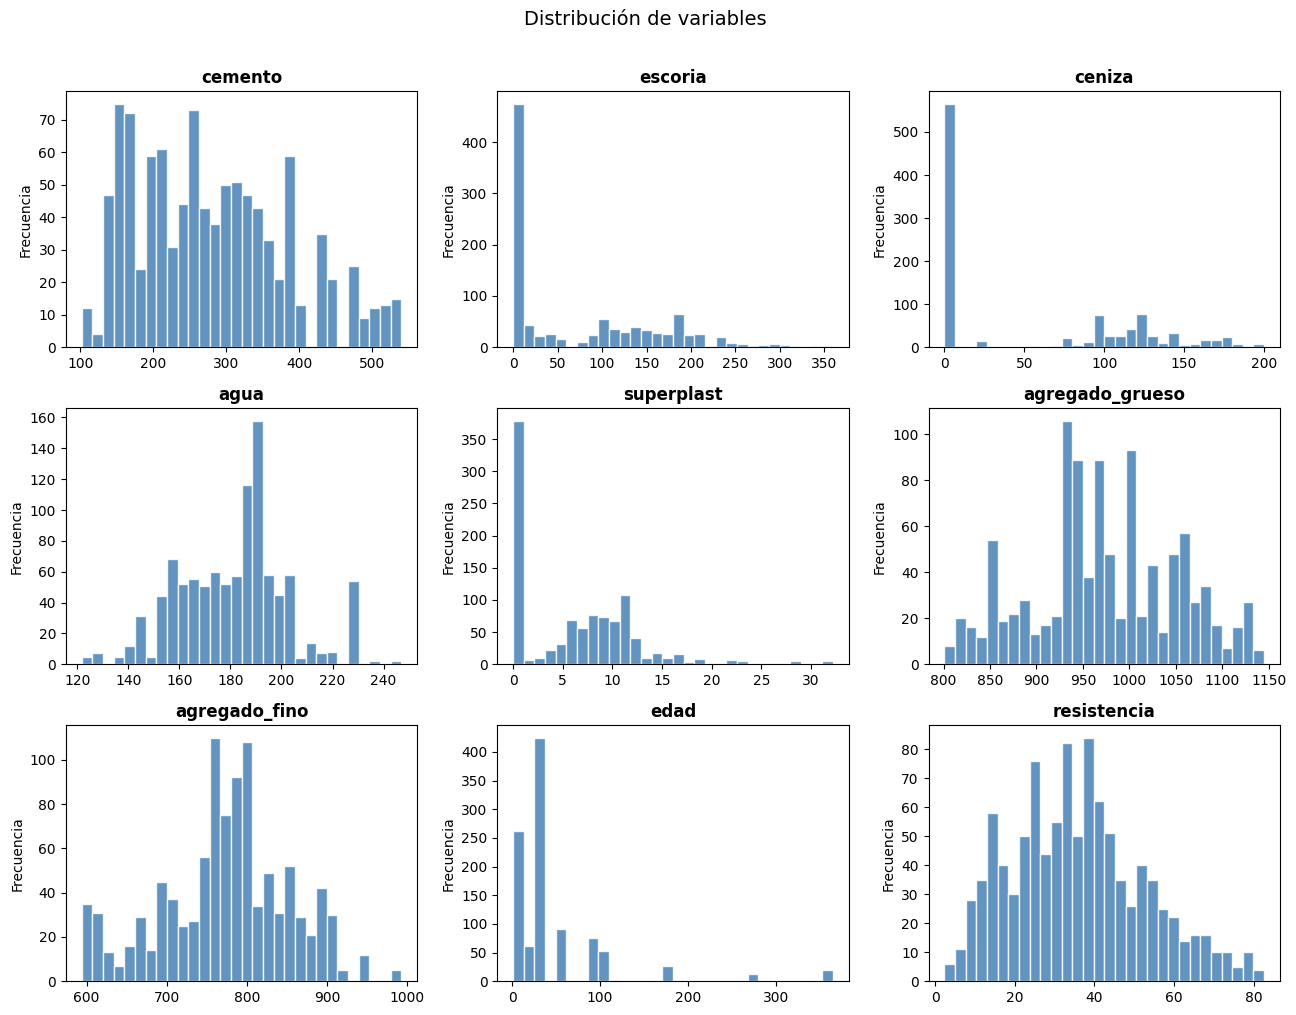

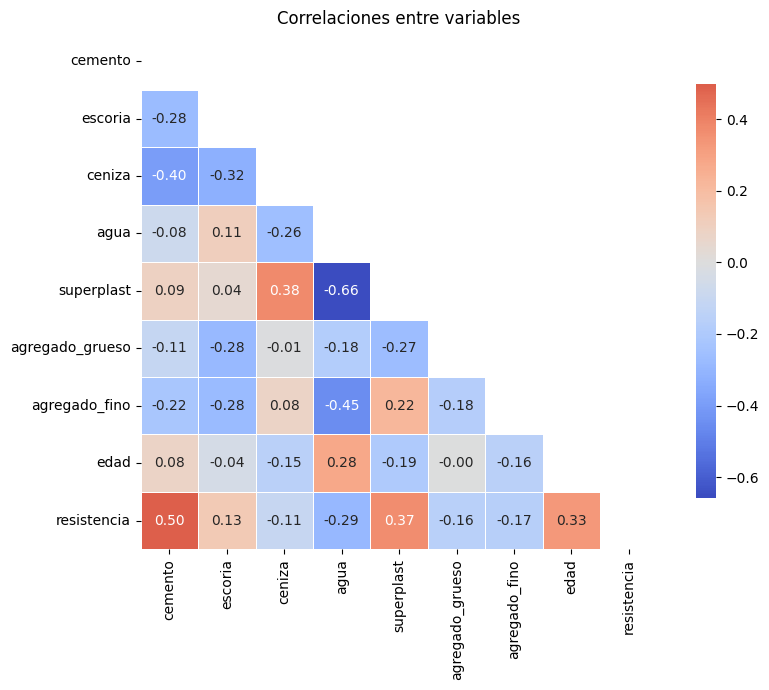

In [41]:
# Exploración visual
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Distribución de variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Mapa de correlación
plt.figure(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlaciones entre variables")
plt.tight_layout()
plt.show()

#### **Pregunta 1.2**
**Observa el histograma de edad. Describe su distribución. ¿Es aproximadamente normal? ¿Por qué importa la distribución de las variables de entrada antes de pasarlas a una red neuronal?**

El histograma de edad no parece perfectamente normal debido a que muestra asimetría hacia la derecha gracias a muchos valores en edades bajas y algunos valores altos aislados.

Es importante analizar la distribución de las variables antes de usarlas en una red neuronal porque se nos permite detectar asimetrías, outliers o escalas diferentes, así como también ayuda a decidir si es necesario normalizar o transformar los datos. De igual manera se mejora la estabilidad y el rendimiento del entrenamiento del modelo.


### **Pregunta 1.3**
**Mira el mapa de correlaciones. ¿Cuál variable tiene mayor correlación con resistencia? ¿Eso significa que una red neuronal sólo necesitaría esa variable para predecir bien?**

La variable con mayor correlación con la resistencia es cemento. Sin embargo, esto no significa que una red neuronal sólo necesite esa variable para predecir bien, porque la resistencia del concreto depende de varios factores simultáneamente.

Las redes neuronales aprenden relaciones combinadas y no lineales entre múltiples variables, por lo que variables con menor correlación individual pueden aportar información útil cuando se combinan con otras.

In [42]:
# División y escalado
X = df.drop("resistencia", axis=1).values # shape: (1030, 8)
y = df["resistencia"].values.reshape(-1, 1) # shape: (1030, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=SEED)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val: {X_val.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")

# Escalado
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc = scaler_X.transform(X_val)
X_test_sc = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc = scaler_y.transform(y_val)
y_test_sc = scaler_y.transform(y_test)

Train: 700 muestras
Val: 124 muestras
Test: 206 muestras


#### **Pregunta 1.4**
**Esta vez hay tres conjuntos: train, val y test. ¿Cuál es la función específica del conjunto de validación que no puede cumplir el conjunto de prueba? Si usaras el test set para early stopping, ¿qué error conceptual estarías cometiendo?**

La función que tiene el conjunto de validación es para evaluar el modelo durante el entrenamiento y ajustar hiperparámetros. El conjunto de pruebas no podría cumplir esta función porque debe permanecer completamente independiente para medir el rendimiento final del modelo en datos no vistos.

Si se usara el conjunto de pruebas para early stopping se cometería el error de ajustar indirectamente el modelo a los datos de prueba, lo que produciría una estimación optimista del rendimiento y dejaría de ser una evaluación independiente.


#### **Pregunta 1.5**
**X_val_sc y X_test_sc usan .transform(), no .fit_transform(). Explica por qué esto es importante en términos de lo que el modelo "puede saber" sobre los datos. ¿Qué nombre tiene este tipo de error cuando se comete?**

Usan `.transform()` porque deben escalarse usando los mismos parámetros cálculados únicamente con el train set. Si se usara `.fit_transform()`, el escalador aprendería información estadística de los conjuntos de validación o prueba, permitiendo que el modelo "vea" información que no debería conocer durante el entrenamiento. Este error se conoce como fuga de datos (data leakage)

#### **Pregunta 1.6**
**Estamos escalando también _y_. Escalar el target no siempre es necesario en regresión lineal, pero en redes neuronales es común. Menciona dos razones técnicas por las que escalar el target puede ayudar al entrenamiento de una red.**

Escalar el target puede ayudar en redes neuronales por varias razones:

**1. Estabilidad numérica en el entrenamiento:** Valores más pequeños y centrados facilitan el cálculo del gradiente y evitan actualizaciones demasiado grandes en los pesos.

**2. Mejor convergencia del optimizador:** Cuando la escala del target es similar a la de las entradas, el proceso de optimización suele converger más rápido y de forma más estable.



In [43]:
# Conversión a Tensores
def to_tensor(array):
    return torch.tensor(array, dtype=torch.float32).to(device)

X_train_t = to_tensor(X_train_sc)
X_val_t = to_tensor(X_val_sc)
X_test_t = to_tensor(X_test_sc)
y_train_t = to_tensor(y_train_sc)
y_val_t = to_tensor(y_val_sc)
y_test_t = to_tensor(y_test_sc)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Tensor train X: {X_train_t.shape} dtype={X_train_t.dtype}")
print(f"Tensor train y: {y_train_t.shape} dtype={y_train_t.dtype}")

Tensor train X: torch.Size([700, 8]) dtype=torch.float32
Tensor train y: torch.Size([700, 1]) dtype=torch.float32


#### **Pregunta 1.7**
**¿Por qué usamos float32 y no float64 (doble precisión)? ¿Cuándo el uso de float64 podría ser importante?**

Se usan datos de tipo float32 (de precisión simple) ya que datos de float32 ocupan la mitad de memoria que float64, además que las GPUs están altamente optimizadas para realizar operaciones con float32 de manera muy eficiente, por lo que la precisión que ofrece float32 es clave para la mayoría de tareas de Deep Learning, relacionando eficiencia y rendimiento en el entrenamiento de redes neuronales.

El uso de float64 podría ser importante donde la precisión numérica extrema es crítica, en escenarios como simulaciones y cálculo científico, modelos que tengan alta sensibilidad a la estabilidad numérica, además de que cambiar a float64 puede ayudar a diagnosticar problemas de entrrenamiento causados por problemas de precisión numérica.

#### **Pregunta 1.8**
**DataLoader recibe shuffle=True. En clase viste qué es un epoch (slide 104 del lunes). ¿Por qué tiene sentido mezclar los datos en cada epoch? ¿Qué problema concreto estás evitando?**

Mezclar los datos en cada epoch ayuda a evitar varios problemas como el sobreajuste al orden de los datos, reduce el riesgo de ciclos de aprendizaje, así como también mejora la exploración del espacio de parámetros y ayuda a simular la variabilidad de datos reales.

El problema concreto que se evita es el sobreajuste al orden de presentación de los datos y la inestabilidad en el proceso de optimización, lo que a su vez previene un rendimiento deficiente en datos no vistos, es decir, una mala generalización.

---


## **Parte 2: El forward pass**

In [44]:
# Forward pass manual con números pequeños, se considera una red con:

## 2 entradas: x1 = 0.5, x2 = -1.0
x = [0.5, -1.0]
## 1 capa oculta con 2 neuronas y activación ReLU
## 1 neurona de salida (sin activación)


# Capa 1 — W1 (2×2) y b1 (2):
W1 = [[0.3, -0.5], [0.8,  0.2]]
b1 = [0.1, -0.3]

# Capa 2 — W2 (1×2) y b2 (1):
W2 = [[0.6, -0.4]]
b2 = [0.0]

# Cálculo paso a paso
## 1. Pre-activación capa 1 (z1 = W1·x + b1)
z1 = [W1[0][0]*x[0] + W1[0][1]*x[1] + b1[0], W1[1][0]*x[0] + W1[1][1]*x[1] + b1[1]]
## Activación
a1 = [max(0, z1[0]), max(0, z1[1])] # ReLU(Z1)

## 2. Pre-activación capa 2 (z2 = W2·a1 + b2)
z2 = W2[0][0]*a1[0] + W2[0][1]*a1[1] + b2[0]

# 3. Salida
y_hat = z2

print("z1 =", z1)
print("a1 =", a1)
print("y_hat =", y_hat)

z1 = [0.75, -0.09999999999999998]
a1 = [0.75, 0]
y_hat = 0.44999999999999996


**Si el valor real fuera y = 2.0, ¿cuánto vale MSE para este ejemplo?**

Sabemos que MSE está dado por la siguiente fórmula:

MSE = $\frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$
, por lo tanto:


In [45]:
y_real = 2.0
mse = (y_hat - y_real) ** 2
print("MSE =", mse)

MSE = 2.4025000000000003


Ahora se verifican los cálculos con ayuda de PyTorch

In [46]:
# Red de verificación (NO es el modelo final, es solo para verificar el cálculo manual)
x_toy  = torch.tensor([[0.5, -1.0]])
W1 = torch.tensor([[0.3, -0.5], [0.8, 0.2]])  # PyTorch: filas = neuronas de salida
# Se corrige un error en W1 ya que se encontraban valores cambiados entre x2 y y1 (aparecía como {[0.3, 0.8], [-0.5, 0.2]}, dejando de coincidir con el W1 calculado "a mano")
b1 = torch.tensor([[0.1, -0.3]])
W2 = torch.tensor([[0.6, -0.4]])
b2 = torch.tensor([[0.0]])

z1 = x_toy @ W1.T + b1
a1 = torch.relu(z1)
z2 = a1 @ W2.T + b2

print(f"z1 = {z1}")
print(f"a1 = {a1}")
print(f"z2 (ŷ) = {z2}")
y_toy = torch.tensor([[2.0]])
mse = ((z2 - y_toy) ** 2).mean()
print(f"MSE = {mse.item():.6f}")

z1 = tensor([[ 0.7500, -0.1000]])
a1 = tensor([[0.7500, 0.0000]])
z2 (ŷ) = tensor([[0.4500]])
MSE = 2.402500


#### **Pregunta 2.1**
**Muestra aquí tu cálculo manual paso a paso. ¿Coincide con la salida del código? Si hay discrepancia, ¿dónde está el error?**

Comparando los resultados de la parte a mano con la parte de PyTorch, (realizando el ajuste en base al error observado entre el primer y el segundo W1) apreciamos los mismos resultados tanto en z1, a1, y_gorro y MSE. No se muestra error, solo que en PyTorch se ven resultados "cerrados" y en el cálculo a mano no redondee la impresión de los resultados.


#### **Pregunta 2.2**
**En el paso de ReLU, si Z1[1] hubiera sido negativo, ¿qué valor tomaría A1[1]? ¿Qué implicación tiene eso para el gradiente de esa neurona durante backpropagation? ¿Cómo se llama ese fenómeno?**

Como se obtuvo que Z1[1] es negativo (-0.1), el valor que tomó A1[1] es 0, causando un "bloqueo" en la retropropagación, ya que al multiplicarse por cero el gradiente, se anula. En consecuencia, los pesos y el sesgo de esa neurona no se actualizarán en lo absoluto durante el paso del entrenamiento. Este fenómeno se conoce como Dying ReLU, consiste en que si una neurona recibe de manera constante valores negativos, esta "muere" permanentemente porque su gradiente siempre será cero, impidiendo que el optimizador pueda ajustarla para que vuelva a ser útil.

In [47]:
# Definición del modelo
class ConcreteNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0):
        super(ConcreteNet, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.network(x)

model = ConcreteNet(input_dim=8, hidden_dim=64, output_dim=1, dropout_rate=0.0).to(device)
print(model)
print(f"\nTotal de parámetros: {sum(p.numel() for p in model.parameters()):,}")

ConcreteNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total de parámetros: 4,801


#### **Pregunta 2.3**
**El código imprime el total de parámetros automáticamente. Antes de ejecutar la celda, calcula ese número a mano para la arquitectura 8 -> 64 -> 64 -> 1. Muestra el desglose por capa (pesos + sesgos). ¿Coincide?**

Cada capa lineal tiene pesos + sesgos.

      Capa 1: Linear(8 → 64)
      - Pesos: 8 × 64 = 512  
      - Bias: 64  
      - Total capa 1: 576

      Capa 2: Linear(64 → 64)
      - Pesos: 64 × 64 = 4096  
      - Bias: 64  
      - Total capa 2: 4160

      Capa 3: Linear(64 → 1)
      - Pesos: 64 × 1 = 64
      - Bias: 1
      - Total capa 3: 65

Total de parámetros: 576 + 4160 + 65 = 4,801

Sí, el cálculo manual coincide exactamente con el valor que imprime PyTorch.

#### **Pregunta 2.4**
**La capa de salida no tiene función de activación. ¿Por qué? ¿Qué pasaría si agregáramos ReLU al final en este problema? ¿Podría eso causar un error sistemático en las predicciones?**

La capa de salida no tiene función de activación porque este es un
problema de regresión. El objetivo del modelo es predecir un valor continuo (resistencia del concreto en MPa), por lo que la salida debe poder tomar cualquier valor real.

Si agregáramos ReLU en la capa final, la salida quedaría restringida a valores mayores o iguales a cero, ya que ReLU convierte todos los valores negativos en cero.

Aunque la resistencia del concreto normalmente es positiva, esto podría introducir un sesgo en el modelo.

#### **Pregunta 2.5**
**nn.Sequential es una alternativa a escribir `forward()` manualmente. ¿Cuándo sería necesario escribir `forward()` explícitamente en lugar de usar nn.Sequential? Piensa en arquitecturas más complejas.**

`nn.Sequential` es útil cuando la arquitectura de la red es simplemente una cadena lineal de capas, donde cada capa recibe la salida de la anterior.

Sin embargo, en arquitecturas más complejas es necesario escribir el método `forward()` explícitamente, ya que el flujo de datos no es estrictamente secuencial.

Por ejemplo:

- Redes con múltiples entradas o salidas
- Arquitecturas con conexiones residuales
- Modelos con operaciones condicionales o lógica personalizada
- Arquitecturas con concatenaciones o combinaciones de tensores

Shape de W₁: torch.Size([64, 8])
Media de W₁: 0.0037
Std de W₁: 0.2018
Min de W₁: -0.3519
Max de W₁: 0.3502


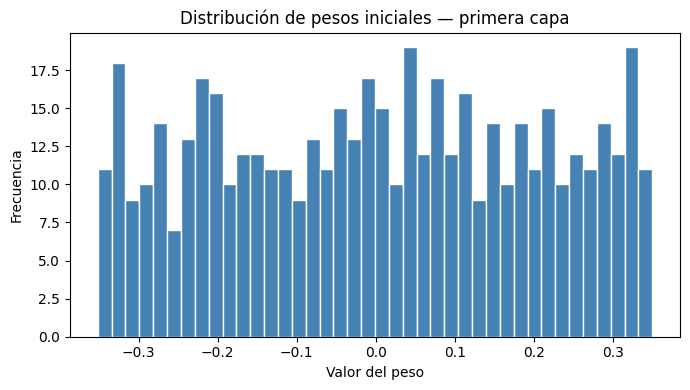

In [48]:
# Inspección de pesos adicionales

# Observar cómo PyTorch inicializa los pesos
primera_capa = list(model.parameters())[0]  # W de la primera capa: shape (64, 8)
print(f"Shape de W₁: {primera_capa.shape}")
print(f"Media de W₁: {primera_capa.data.mean():.4f}")
print(f"Std de W₁: {primera_capa.data.std():.4f}")
print(f"Min de W₁: {primera_capa.data.min():.4f}")
print(f"Max de W₁: {primera_capa.data.max():.4f}")

plt.figure(figsize=(7, 4))
plt.hist(primera_capa.data.cpu().numpy().flatten(), bins=40,
         color="steelblue", edgecolor="white")
plt.title("Distribución de pesos iniciales — primera capa")
plt.xlabel("Valor del peso")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

#### **Pregunta 2.6**
**¿Qué distribución tienen los pesos iniciales? PyTorch usa por default la inicialización de Kaiming He para capas con ReLU. ¿Por qué no inicializar todos los pesos en cero? ¿Qué problema fundamental causaría eso durante el entrenamiento? (Pista: piensa en lo que haría backpropagation si todos los pesos fueran idénticos.)**


---

## **Parte 3: El ciclo de entrenamiento**
Parte central de la actividad donde se construirá el training loop explícito de PyTorch, que es exactamente el ciclo `forward -> loss -> backward -> actualizar` que viste en los slides del lunes.



In [49]:
# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

#### **Pregunta 3.1**
**Se usa `MSELoss`. ¿Por qué MSE y no cross-entropy? ¿En qué tipo de tarea usarías cross-entropy binary y en cuál usarías cross-entropy multiclase?**

Se usa `MSELoss` porque el problema que estamos resolviendo es de regresión, es decir, el modelo predice un valor continuo (la resistencia del concreto).

La _cross-entropy_ se utiliza en problemas de clasificación, donde la salida del modelo representa probabilidades de pertenecer a una clase.

- **Binary cross-entropy** se usa cuando hay **dos clases** (por ejemplo: spam vs no spam, aprobado vs reprobado).
- **Cross-entropy multiclase** se usa cuando existen **más de dos categorías posibles** (por ejemplo: clasificar imágenes entre perro, gato, caballo, etc.).

En este problema no estamos prediciendo clases sino un valor numérico, por lo que MSE es la función de pérdida adecuada.

#### **Pregunta 3.2**
**El optimizador es Adam con lr=1e-3. En clase viste que Adam mantiene estimaciones del primer y segundo momento del gradiente. Explica con tus palabras qué significa que los parámetros que "varían mucho" reciban pasos más pequeños. ¿Por qué eso puede ser ventajoso frente a un learning rate fijo para todos los parámetros?**

Adam adapta el tamaño del paso de cada parámetro utilizando estadísticas del gradiente. Cuando un parámetro tiene gradientes que cambian mucho de magnitud entre iteraciones, Adam interpreta que esa dirección es inestable y reduce el tamaño del paso para evitar oscilaciones grandes durante la actualización.

En cambio, si un parámetro tiene gradientes pequeños o consistentes, el optimizador puede permitir pasos relativamente mayores.

Esto es ventajoso frente a usar un learning rate fijo para todos los parámetros, porque en una red neuronal distintas capas o pesos pueden aprender a ritmos diferentes. Adam ajusta automáticamente ese ritmo, lo que suele hacer el entrenamiento más estable y más rápido en converger.

In [50]:
# Training Loop con Early Stopping
def train_model(model, train_loader, X_val_t, y_val_t,
                n_epochs=300, patience=20, verbose_every=25):
    """
    Entrena el modelo con early stopping basado en val loss.

    Args:
        patience : cuántos epochs tolerar sin mejora en val loss
                   antes de detener el entrenamiento.
    Returns:
        Historial de train loss y val loss por epoch.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_history = []
    val_history = []

    # Variables para early stopping
    best_val_loss = float("inf")
    best_weights = None
    epochs_no_improv = 0
    stopped_at = n_epochs

    for epoch in range(n_epochs):

        # ── MODO ENTRENAMIENTO ──────────────────────────────────────
        model.train()
        batch_losses = []

        for X_batch, y_batch in train_loader:

            # Paso 1: limpiar gradientes acumulados
            optimizer.zero_grad()

            # Paso 2: forward pass
            y_pred = model(X_batch)

            # Paso 3: calcular pérdida
            loss = criterion(y_pred, y_batch)

            # Paso 4: backward pass (calcular gradientes)
            loss.backward()

            # Paso 5: actualizar pesos
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)
        train_history.append(train_loss)

        # ── MODO EVALUACIÓN ─────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_history.append(val_loss)

        # ── EARLY STOPPING ──────────────────────────────────────────
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improv = 0
        else:
            epochs_no_improv += 1

        if epochs_no_improv >= patience:
            stopped_at = epoch + 1
            print(f"  Early stopping en epoch {stopped_at}.")
            break

        if (epoch + 1) % verbose_every == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # Restaurar los mejores pesos encontrados
    if best_weights is not None:
        model.load_state_dict(best_weights)

    return train_history, val_history, stopped_at


# Entrenamiento
print("Entrenando modelo base...")
train_hist, val_hist, stopped = train_model(model, train_loader, X_val_t, y_val_t)
print(f"Entrenamiento completado. Detenido en epoch {stopped}.")

Entrenando modelo base...
  Epoch  25 | Train: 0.0916 | Val: 0.1374
  Epoch  50 | Train: 0.0543 | Val: 0.1169
  Epoch  75 | Train: 0.0419 | Val: 0.1100
  Epoch 100 | Train: 0.0344 | Val: 0.1070
  Early stopping en epoch 114.
Entrenamiento completado. Detenido en epoch 114.


#### **Pregunta 3.3**
**La más importante de esta sección. Explica con tus propias palabras qué hace cada uno de los 5 pasos dentro del loop de batches. No copies las definiciones de los slides: formula la explicación en términos de lo que está ocurriendo matemáticamente con los pesos de esta red específica, con este dataset concreto.**

1. Primero, el modelo recibe un batch de datos de entrada (las variables del concreto) y realiza una **predicción** mediante el forward pass. Matemáticamente, esto significa aplicar las transformaciones lineales y funciones de activación de la red para producir un valor estimado de la resistencia del concreto.

2. Después se calcula la **función de pérdida (MSE)** comparando la predicción del modelo con el valor real del dataset. Esta pérdida mide qué tan lejos están las predicciones de los valores reales para ese batch.

3. Luego se ejecuta **`loss.backward()`**, que calcula el gradiente de la pérdida con respecto a cada peso de la red. Es decir, determina cómo debería cambiar cada peso para reducir el error observado en ese batch.

4. Una vez que se tienen los gradientes, el optimizador usa esa información para **actualizar los pesos**. En este caso Adam ajusta cada peso en dirección opuesta al gradiente, con un tamaño de paso controlado por el learning rate y sus estimaciones internas.

5. Finalmente, el proceso se repite con el siguiente batch. Al hacerlo muchas veces sobre todo el dataset, los pesos se van ajustando progresivamente hasta que el modelo logra aproximar la relación entre las variables del concreto y su resistencia.

#### **Pregunta 3.4**
**`optimizer.zero_grad()` está dentro del loop de batches, no fuera. ¿Qué pasaría si lo movieras fuera del loop (es decir, que se ejecutara solo una vez al inicio de cada epoch)? ¿Los pesos se actualizarían correctamente?**

Si `optimizer.zero_grad()` se moviera fuera del loop de batches, los gradientes no se reiniciarían en cada iteración y comenzarían a acumularse entre batches. Esto significa que los gradientes calculados para un batch se sumarían con los de los siguientes, produciendo actualizaciones cada vez más grandes y distorsionadas, causando que los pesos no se actualicen correctamente porque cada paso del optimizador estaría usando información mezclada de múltiples batches en lugar del gradiente específico del batch actual.

#### **Pregunta 3.5**
**El bloque de evaluación usa `model.eval()` y `torch.no_grad()`. Son dos cosas distintas:**

- **`model.eval()` cambia el comportamiento de ciertas capas. ¿Cuáles capas de tu modelo se comportan diferente en modo evaluación vs entrenamiento, y por qué?**
- **`torch.no_grad()` evita que PyTorch construya el grafo computacional. ¿Qué es ese grafo y para qué lo usa backpropagation? ¿Por qué no lo necesitas durante la evaluación?**

`model.eval()` cambia el comportamiento de capas que dependen del modo de entrenamiento, principalmente Dropout y Batch Normalization. Durante el entrenamiento, Dropout apaga aleatoriamente algunas neuronas para evitar sobreajuste, mientras que BatchNorm usa estadísticas calculadas del batch actual.

En modo evaluación, Dropout se desactiva y BatchNorm usa las estadísticas acumuladas durante el entrenamiento para producir predicciones consistentes.

Por otro lado, `torch.no_grad()` evita que PyTorch construya el grafo computacional, que es la estructura que registra todas las operaciones matemáticas realizadas durante el forward pass. Backpropagation utiliza ese grafo para aplicar la regla de la cadena y calcular los gradientes de la pérdida con respecto a cada parámetro.

Durante la evaluación no se calculan gradientes ni se actualizan pesos, por lo que construir ese grafo sería innecesario y solo consumiría más memoria y tiempo de cómputo.

#### **Pregunta 3.6**
**El early stopping implementado guarda best_weights y los restaura al final con model.load_state_dict(best_weights). ¿Por qué es necesario ese paso de restauración? ¿Qué le estarías devolviendo al usuario si no lo hicieras?**

Durante el entrenamiento, el modelo puede seguir actualizando sus pesos incluso después de haber alcanzado su mejor desempeño en el conjunto de validación. Early Stopping detecta ese punto guardando los pesos del modelo cuando la pérdida de validación es mínima.

Restaurar `best_weights` al final garantiza que el modelo que se devuelve sea el que logró el mejor rendimiento durante el entrenamiento, no simplemente el estado final después de la última época.

Si no se hiciera esa restauración, se estaría devolviendo al usuario el modelo con los últimos pesos entrenados que podrían corresponder a un punto donde el modelo ya comenzó a sobreajustar o donde la pérdida de validación empeoró.

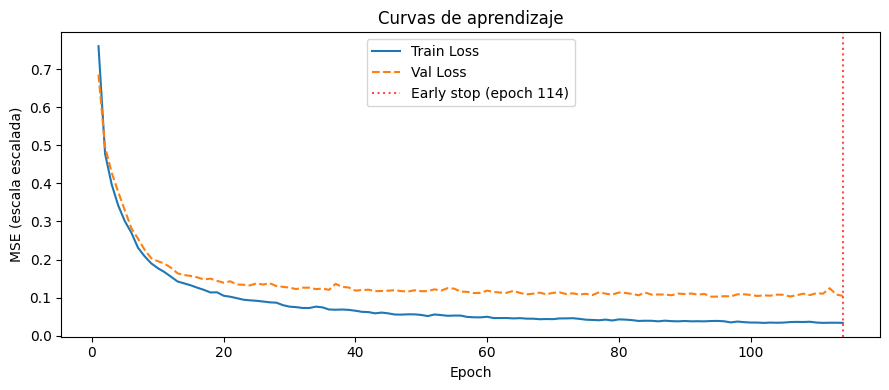

In [51]:
# Curvas de Aprendizaje
def plot_learning_curves(train_hist, val_hist, stopped_at, title="Curvas de aprendizaje"):
    plt.figure(figsize=(9, 4))
    epochs = range(1, len(train_hist) + 1)
    plt.plot(epochs, train_hist, label="Train Loss", linewidth=1.5)
    plt.plot(epochs, val_hist,   label="Val Loss",   linewidth=1.5, linestyle="--")
    plt.axvline(x=stopped_at, color="red", linestyle=":", alpha=0.7,
                label=f"Early stop (epoch {stopped_at})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (escala escalada)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curves(train_hist, val_hist, stopped)

#### **Pregunta 3.7**
**Pega tu gráfica aquí y describe lo que ves. Responde específicamente:**

**a) ¿El val loss converge suavemente o tiene ruido? ¿A qué atribuyes eso?**

El *validation loss* no converge de forma completamente suave; se observan pequeñas fluctuaciones. Esto es normal porque la evaluación se realiza sobre un conjunto finito de datos y porque el entrenamiento ocurre por batches, lo que introduce cierta variabilidad en los gradientes y en las actualizaciones de los pesos. Además, al tratarse de un dataset relativamente pequeño, pequeñas variaciones en las predicciones pueden producir cambios visibles en la pérdida de validación.

**b) ¿Hay señal de overfitting? ¿Cómo lo identificas visualmente — no con un número, sino con la forma de las curvas?**

Se puede identificar una señal de overfitting cuando la curva de *training loss* continúa disminuyendo mientras que la curva de *validation loss* deja de mejorar o empieza a aumentar. Visualmente esto se observa como una separación entre ambas curvas: el modelo sigue ajustándose mejor a los datos de entrenamiento, pero ya no mejora, o incluso empeora su desempeño en los datos de validación.

**c) ¿La línea de early stopping está "en el lugar correcto", o debería haber esperado más o parado antes?**

La línea de early stopping parece estar ubicada en un punto razonable, ya que corresponde aproximadamente al momento donde el *validation loss* alcanza su valor mínimo antes de comenzar a estabilizarse o empeorar ligeramente. Esto indica que el entrenamiento se detuvo cerca del punto donde el modelo generaliza mejor, evitando continuar hacia una región donde el overfitting podría aumentar.

-----

## **Parte 4: Evaluación en escala original**

In [52]:
# Métricas
def evaluate(model, X_t, y_true_sc, scaler_y, label=""):
    model.eval()
    with torch.no_grad():
        y_pred_sc = model(X_t).cpu().numpy()
    y_pred_mpa = scaler_y.inverse_transform(y_pred_sc)
    y_true_mpa = scaler_y.inverse_transform(y_true_sc)
    rmse = np.sqrt(mean_squared_error(y_true_mpa, y_pred_mpa))
    mae  = np.mean(np.abs(y_true_mpa - y_pred_mpa))
    if label:
        print(f"{label:30s} | RMSE: {rmse:.2f} MPa | MAE: {mae:.2f} MPa")
    return rmse, mae, y_pred_mpa, y_true_mpa

rmse_nn, mae_nn, y_pred_mpa, y_true_mpa = evaluate(
    model, X_test_t, y_test_sc, scaler_y, "Red Neuronal (base)"
)

Red Neuronal (base)            | RMSE: 5.22 MPa | MAE: 3.61 MPa


#### **Pregunta 4.1**
**Reportas tanto RMSE como MAE. ¿En qué se diferencian conceptualmente? Si el RMSE es notablemente mayor que el MAE, ¿qué sugiere eso sobre los errores del modelo?**

Conceptualmente, ambas métricas miden el error promedio entre las predicciones del modelo y los valores reales, pero lo hacen de manera distinta. El Mean Absolute Error calcula el promedio de los errores absolutos, por lo que todos los errores contribuyen de forma proporcional. En cambio, el Root Mean Squared Error eleva los errores al cuadrado antes de promediarlos y luego aplica la raíz cuadrada, lo que hace que los errores grandes tengan un peso mucho mayor en la métrica.

Si el RMSE es notablemente mayor que el MAE, nos sugiere que el modelo está cometiendo outliers (o errores grandes). Es decir, la mayoría de las predicciones pueden estar relativamente cerca del valor real, pero existen ciertos casos donde el modelo falla de forma considerable y esos errores grandes afectan más al RMSE que al MAE.

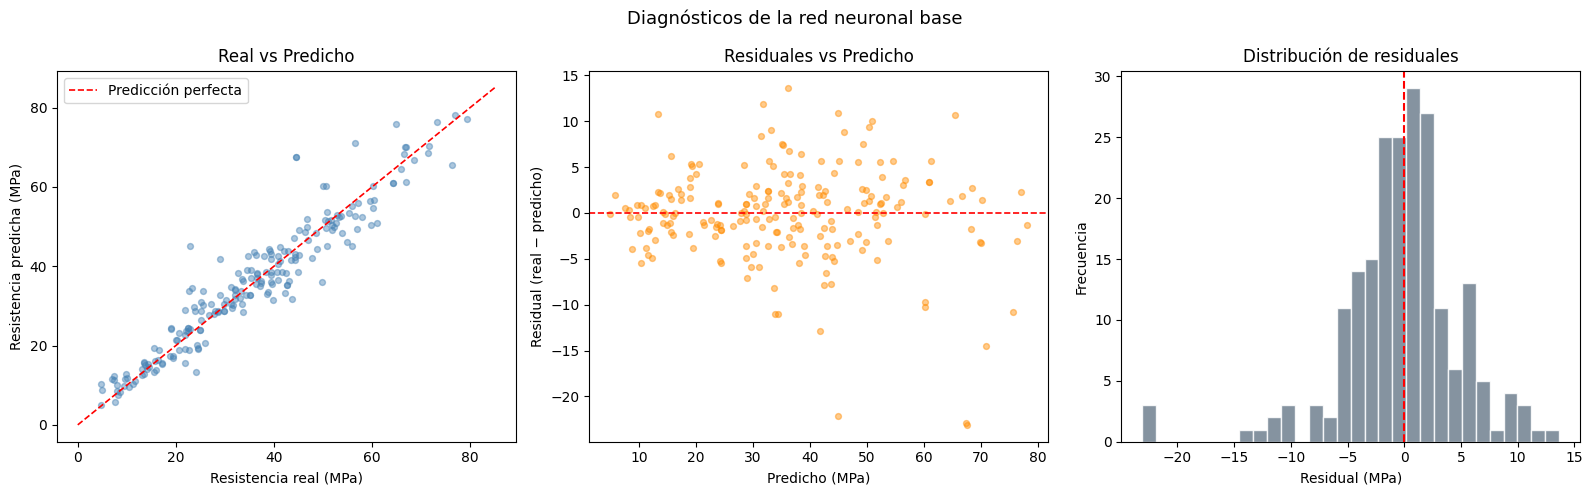

Media de residuales: -0.199
Std  de residuales: 5.213


In [53]:
# Gráficas diagnósticas
residuals = y_true_mpa.flatten() - y_pred_mpa.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Real vs Predicho
ax = axes[0]
ax.scatter(y_true_mpa, y_pred_mpa, alpha=0.45, s=18, color="steelblue")
lims = [0, 85]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Predicción perfecta")
ax.set_xlabel("Resistencia real (MPa)")
ax.set_ylabel("Resistencia predicha (MPa)")
ax.set_title("Real vs Predicho")
ax.legend()

# Gráfica 2: Residuales vs Predicho
ax = axes[1]
ax.scatter(y_pred_mpa, residuals, alpha=0.45, s=18, color="darkorange")
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicho (MPa)")
ax.set_ylabel("Residual (real − predicho)")
ax.set_title("Residuales vs Predicho")

# Gráfica 3: Distribución de residuales
ax = axes[2]
ax.hist(residuals, bins=30, color="slategray", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual (MPa)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de residuales")

plt.suptitle("Diagnósticos de la red neuronal base", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Media de residuales: {residuals.mean():.3f}")
print(f"Std  de residuales: {residuals.std():.3f}")

#### **Pregunta 4.2**
**Pega las tres gráficas. Para cada una, escribe al menos dos observaciones:**

- **Real vs Predicho: ¿hay sesgo sistemático? ¿el modelo predice igual de bien en valores bajos que en valores altos de resistencia?**

En la gráfica de _Real vs Predicho_ se observa que la mayoría de los puntos se distribuyen alrededor de la línea diagonal, lo que indica que el modelo logra capturar razonablemente la relación entre las variables y la resistencia del concreto. No se observa un sesgo fuerte hacia sobreestimar o subestimar en todo el rango.

- **Residuales vs Predicho: ¿hay homocedasticidad o el patrón de los errores cambia con el valor predicho?**

En la gráfica de _residuales vs predicho_ los errores tienden a distribuirse alrededor de cero, lo cual es una señal positiva porque indica que el modelo no presenta un sesgo en una dirección específica.

No obstante, se puede apeciar cierta variación en la dispersión de los errores a lo largo del rango de valores predichos. En algunos rangos los residuales parecen más dispersos, lo que sugiere que la varianza de los errores no es completamente constante.

- **Distribución de residuales: ¿es aproximadamente simétrica? ¿hay outliers evidentes?**

La _distribución de los residuales_ parece aproximadamente centrada en cero y relativamente simétrica, lo que indica que el modelo no tiende a sobreestimar o subestimar de manera consistente.

Aun así, se notan algunos valores alejados del centro que corresponden a posibles outliers, lo cual es esperable en modelos de regresión aplicados a datos reales.

#### **Pregunta 4.3**
**El supuesto de normalidad de residuales importaba mucho en regresión lineal para inferencia estadística (intervalos de confianza, p-values). En una red neuronal entrenada por minimización de MSE, ¿ese supuesto sigue siendo necesario? ¿Qué sí y qué no cambia?**

En una red neuronal entrenada minimizando MSE, el supuesto de normalidad de los residuales no es estrictamente necesario para que el modelo funcione o para que el entrenamiento sea válido. El objetivo del entrenamiento es simplemente encontrar los parámetros que minimicen el error cuadrático medio, independientemente de la distribución exacta de los errores.

Lo que sí cambia es que en redes neuronales normalmente el objetivo principal es la predicción, no la inferencia estadística. Por eso no necesitamos que los residuales sean normales para calcular p-values o intervalos de confianza como en regresión lineal clásica.


---

## **Parte 5: Experimentos Sistemáticos**
La regla de esta parte es estricta: cambia solo una cosa por experimento. Si cambias dos variables simultáneamente, no puedes saber qué causó qué. Es el mismo principio que un experimento controlado en laboratorio.

In [54]:
# Experimento 1: Learning Rate
def experimento_lr(lr_list, n_epochs=300):
    resultados = {}
    for lr in lr_list:
        m = ConcreteNet(8, 64, 1, dropout_rate=0.0).to(device)
        opt = optim.Adam(m.parameters(), lr=lr)
        crit = nn.MSELoss()
        hist_train, hist_val = [], []
        for _ in range(n_epochs):
            m.train()
            bl = []
            for Xb, yb in train_loader:
                opt.zero_grad()
                loss = crit(m(Xb), yb)
                loss.backward()
                opt.step()
                bl.append(loss.item())
            m.eval()
            with torch.no_grad():
                vl = crit(m(X_val_t), y_val_t).item()
            hist_train.append(np.mean(bl))
            hist_val.append(vl)
        resultados[lr] = (hist_train, hist_val)
        print(f"  lr={lr:.0e} | Val Loss final: {hist_val[-1]:.4f}")
    return resultados

print("Experimento: learning rate")
res_lr = experimento_lr([1e-1, 1e-2, 1e-3, 1e-4])

Experimento: learning rate
  lr=1e-01 | Val Loss final: 0.1406
  lr=1e-02 | Val Loss final: 0.0912
  lr=1e-03 | Val Loss final: 0.1102
  lr=1e-04 | Val Loss final: 0.1262


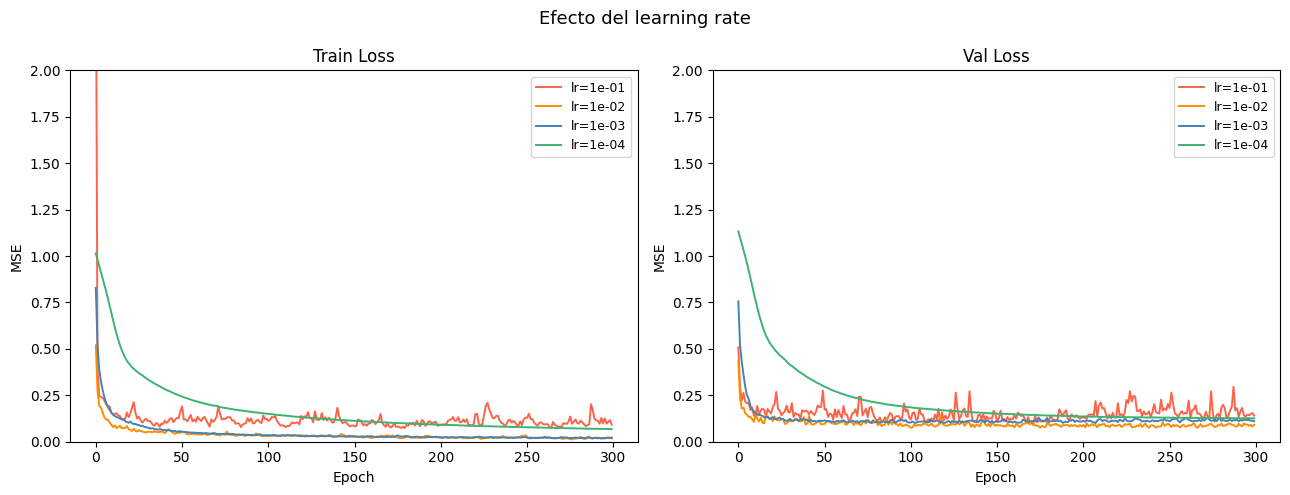

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["tomato", "darkorange", "steelblue", "mediumseagreen"]
lrs    = [1e-1, 1e-2, 1e-3, 1e-4]

for ax_idx, key in enumerate(["Train", "Val"]):
    ax = axes[ax_idx]
    for lr, color in zip(lrs, colors):
        hist = res_lr[lr][ax_idx]
        ax.plot(hist, label=f"lr={lr:.0e}", color=color, linewidth=1.4)
    ax.set_title(f"{key} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 2.0)

plt.suptitle("Efecto del learning rate", fontsize=13)
plt.tight_layout()
plt.show()

#### **Pregunta 5.1**
**Pega la gráfica. Describe el comportamiento para cada learning rate. ¿Cuál diverge, cuál converge demasiado lento, cuál tiene el mejor balance? Conecta lo que ves con lo que viste en los slides 100–102 del lunes.**

En la gráfica se comparan cuatro valores de learning rate: _0.1, 0.01, 0.001 y 0.0001_.

El _learning rate = 0.1_ muestra un comportamiento inestable. La pérdida oscila bastante y en algunos momentos incluso aumenta, lo que indica que el modelo está dando pasos demasiado grandes en el proceso de optimización. Esto puede hacer que el entrenamiento diverja o que no logre acercarse correctamente al mínimo de la función de pérdida.

El _learning rate = 0.0001_ converge de forma muy lenta. La pérdida disminuye de manera estable pero muy gradual, lo que significa que los pasos de actualización de los pesos son demasiado pequeños y el modelo tarda mucho en mejorar.

El _learning rate = 0.001_ también converge lentamente pero de forma más eficiente que 0.0001. La pérdida disminuye de manera estable y progresiva durante el entrenamiento.

El _learning rate = 0.01_ parece ofrecer el mejor balance entre velocidad y estabilidad. La pérdida disminuye relativamente rápido y sin grandes oscilaciones, lo que indica que el modelo puede acercarse al mínimo de la función de pérdida de manera eficiente.

In [56]:
# Experimento 2: Tamaño del Batch
def experimento_batch(batch_sizes, n_epochs=200):
    resultados = {}
    for bs in batch_sizes:
        loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        m = ConcreteNet(8, 64, 1).to(device)
        opt = optim.Adam(m.parameters(), lr=1e-3)
        crit = nn.MSELoss()
        hist_train, hist_val = [], []
        for _ in range(n_epochs):
            m.train()
            bl = []
            for Xb, yb in loader:
                opt.zero_grad()
                loss = crit(m(Xb), yb)
                loss.backward()
                opt.step()
                bl.append(loss.item())
            m.eval()
            with torch.no_grad():
                vl = crit(m(X_val_t), y_val_t).item()
            hist_train.append(np.mean(bl))
            hist_val.append(vl)
        rmse, _, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y)
        resultados[bs] = {"train": hist_train, "val": hist_val, "rmse_test": rmse}
        print(f"  batch={bs:4d} | Val Loss final: {hist_val[-1]:.4f} | RMSE test: {rmse:.2f} MPa")
    return resultados

print("Experimento: batch size")
res_batch = experimento_batch([8, 32, 128, 824]) # 824 ≈ todo el train set

Experimento: batch size
  batch=   8 | Val Loss final: 0.0964 | RMSE test: 5.22 MPa
  batch=  32 | Val Loss final: 0.0759 | RMSE test: 4.92 MPa
  batch= 128 | Val Loss final: 0.1262 | RMSE test: 5.53 MPa
  batch= 824 | Val Loss final: 0.1050 | RMSE test: 6.35 MPa


#### **Pregunta 5.2**
**Anota los RMSE de prueba para cada batch size. ¿Hay diferencias notables? En clase viste el trade-off entre batch pequeño (gradiente ruidoso) y batch grande (gradiente estable). ¿Ese trade-off se manifiesta en tus resultados? ¿Por qué batch=824 es equivalente a batch gradient descent en este caso?**

Los RMSE de prueba obtenidos para cada batch size fueron:

- batch = 8 → RMSE ≈ 5.22 MPa
- batch = 32 → RMSE ≈ 4.92 MPa
- batch = 128 → RMSE ≈ 5.53 MPa
- batch = 824 → RMSE ≈ 6.35 MPa

Sí se observan diferencias entre los tamaños de batch. El mejor resultado se obtuvo con **batch = 32**, que produjo el RMSE más bajo (4.92 MPa), mientras que el peor desempeño ocurrió con **batch = 824**.

Esto refleja efectivamente trade-off entre batch pequeños y grandes. Cuando el batch es pequeño, el gradiente se calcula usando menos ejemplos, por lo que es una aproximación más ruidosa del gradiente real. Sin embargo, este ruido no siempre es negativo: una cantidad moderada de variabilidad en el gradiente puede ayudar al modelo a explorar mejor el espacio de parámetros y mejorar la generalización.

En este experimento, batch = 32 parece ofrecer el mejor balance entre estabilidad del gradiente y suficiente variabilidad durante el entrenamiento, lo que resulta en el menor error de prueba.

Por otro lado, batch = 824 utiliza todo el dataset para calcular cada actualización, lo que lo convierte en equivalente a _batch gradient descent_. En este caso el gradiente es completamente determinista y no tiene variabilidad entre iteraciones. Aunque esto hace que las actualizaciones sean más estables, también puede reducir la capacidad del modelo de explorar distintas regiones del espacio de parámetros, lo que puede llevar a una peor generalización en los datos de prueba, como se observa en el RMSE más alto.

In [57]:
# Experimento 3: Arquitectura
arquitecturas = {
    "Shallow-64" : {"hidden_dim": 64,  "n_layers": 1},
    "Base (2x64)" : {"hidden_dim": 64,  "n_layers": 2},
    "Deep (3x64)" : {"hidden_dim": 64,  "n_layers": 3},
    "Wide (2x256)" : {"hidden_dim": 256, "n_layers": 2},
    "Tiny (2x16)" : {"hidden_dim": 16,  "n_layers": 2},
}

# Para variar el número de capas necesitas modificar ConcreteNet.
# Aquí tienes una versión flexible:

class FlexNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim, dropout_rate=0.0):
        super(FlexNet, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                       nn.Dropout(p=dropout_rate)]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

resultados_arch = {}
for nombre, cfg in arquitecturas.items():
    torch.manual_seed(SEED)
    m = FlexNet(8, cfg["hidden_dim"], cfg["n_layers"], 1).to(device)
    th, vh, st = train_model(m, train_loader, X_val_t, y_val_t,
                              n_epochs=300, patience=25, verbose_every=999)
    rmse, mae, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y, nombre)
    n_params = sum(p.numel() for p in m.parameters())
    resultados_arch[nombre] = {"rmse": rmse, "params": n_params}

  Early stopping en epoch 128.
Shallow-64                     | RMSE: 5.96 MPa | MAE: 4.46 MPa
  Early stopping en epoch 119.
Base (2x64)                    | RMSE: 5.22 MPa | MAE: 3.61 MPa
  Early stopping en epoch 115.
Deep (3x64)                    | RMSE: 5.39 MPa | MAE: 3.60 MPa
  Early stopping en epoch 104.
Wide (2x256)                   | RMSE: 4.82 MPa | MAE: 3.34 MPa
  Early stopping en epoch 144.
Tiny (2x16)                    | RMSE: 6.45 MPa | MAE: 4.74 MPa


| Arquitectura | Parámetros	RMSE Test (MPa) |
|-----------|-----------|
| Shallow-64 | 5.96 |
| Base (2×64)  | 5.22 |
| Deep (3×64) | 5.39 |
| Wide (2×256) | 4.82 |
| Tiny (2×16)	| 6.45 |

#### **Pregunta 5.3**

**a) ¿El modelo con más parámetros tiene el mejor RMSE? ¿Qué dice eso sobre la relación entre tamaño del modelo y desempeño en datasets pequeños?**

No necesariamente. Aunque el modelo Wide (2×256) obtuvo el mejor RMSE (4.82 MPa), aumentar el número de parámetros no siempre garantiza una mejora en el desempeño. Por ejemplo, la arquitectura Deep (3×64) tiene más capas y potencialmente más parámetros que el modelo base, pero obtuvo un RMSE ligeramente peor (5.39 MPa).

Esto sugiere que en datasets relativamente pequeños, aumentar la complejidad del modelo no siempre se traduce en mejores resultados. Modelos demasiado grandes pueden sobreajustarse o no aprovechar completamente su capacidad debido a la cantidad limitada de datos disponibles.

**b) ¿Cuál arquitectura tiene la mejor relación parámetros/desempeño?**

La arquitectura Base (2×64) parece ofrecer la mejor relación entre número de parámetros y desempeño. Aunque no obtiene el RMSE más bajo, su error (5.22 MPa) es relativamente cercano al mejor resultado mientras mantiene un número de parámetros moderado.

**c) Elige la arquitectura que usarías en producción para este problema específico y justifica la elección considerando no solo el RMSE sino también el número de parámetros.**

Para este problema elegiría la arquitectura Base (2×64) para producción. Aunque el modelo Wide (2×256) obtiene el RMSE más bajo, la mejora en desempeño respecto al modelo base es relativamente pequeña (4.82 vs 5.22 MPa), mientras que el número de parámetros y el costo computacional aumentan considerablemente.

Esto lo hace más adecuado para producción, especialmente cuando se trabaja con datasets pequeños donde modelos muy grandes pueden no aportar mejoras proporcionales en el desempeño.

In [58]:
# Experimento 4: Dropout como regularización
tasas_dropout = [0.0, 0.1, 0.3, 0.5]
resultados_dropout = {}

for rate in tasas_dropout:
    torch.manual_seed(SEED)
    m = ConcreteNet(8, 64, 1, dropout_rate=rate).to(device)
    th, vh, st = train_model(m, train_loader, X_val_t, y_val_t,
                              n_epochs=300, patience=25, verbose_every=999)
    rmse, _, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y,
                              f"Dropout={rate}")
    resultados_dropout[rate] = {"rmse": rmse, "train": th, "val": vh}

  Early stopping en epoch 119.
Dropout=0.0                    | RMSE: 5.22 MPa | MAE: 3.61 MPa
  Early stopping en epoch 181.
Dropout=0.1                    | RMSE: 5.20 MPa | MAE: 3.61 MPa
  Early stopping en epoch 125.
Dropout=0.3                    | RMSE: 6.07 MPa | MAE: 4.59 MPa
  Early stopping en epoch 104.
Dropout=0.5                    | RMSE: 6.62 MPa | MAE: 5.27 MPa


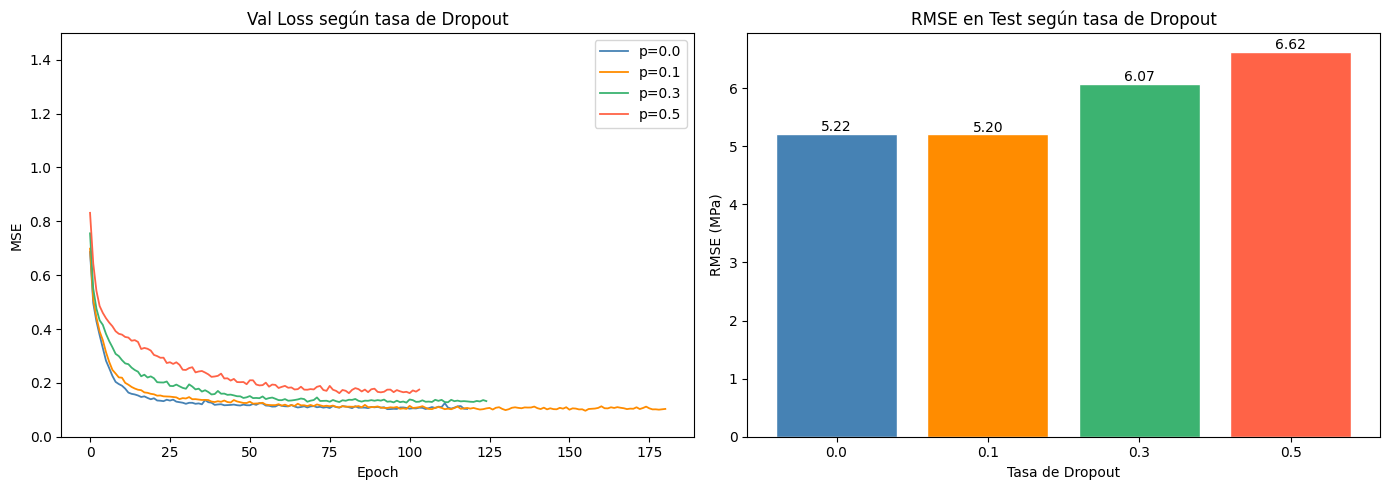

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ["steelblue", "darkorange", "mediumseagreen", "tomato"]

# Curvas val loss
ax = axes[0]
for rate, color in zip(tasas_dropout, colores):
    vh = resultados_dropout[rate]["val"]
    ax.plot(vh, label=f"p={rate}", color=color, linewidth=1.3)
ax.set_title("Val Loss según tasa de Dropout")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.legend(); ax.set_ylim(0, 1.5)

# RMSE final
ax = axes[1]
rmses = [resultados_dropout[r]["rmse"] for r in tasas_dropout]
bars = ax.bar([str(r) for r in tasas_dropout], rmses,
               color=colores, edgecolor="white")
ax.set_title("RMSE en Test según tasa de Dropout")
ax.set_xlabel("Tasa de Dropout"); ax.set_ylabel("RMSE (MPa)")
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

#### **Pregunta 5.4**
**Pega las gráficas. ¿A qué tasa de Dropout se obtiene el mejor RMSE? ¿Tiene sentido intuitivo que Dropout muy alto (0.5) pueda aumentar el error? Explica en términos del concepto de underfitting.**

El mejor RMSE se obtiene con Dropout = 0.1, con un RMSE de 5.20 MPa, ligeramente mejor que el modelo sin Dropout (5.22 MPa). Esto sugiere que una pequeña cantidad de regularización ayuda al modelo a generalizar mejor.

Tiene sentido intuitivo que un Dropout muy alto (0.5) aumente el error porque Dropout funciona desactivando aleatoriamente una fracción de las neuronas durante el entrenamiento para evitar que el modelo dependa demasiado de neuronas específicas, lo que actúa como una forma de regularización.

Sin embargo, cuando la tasa de Dropout es demasiado alta, una gran parte de las neuronas queda inactiva en cada paso de entrenamiento, peligrando que el modelo caiga en _underfitting_, ya que no tiene suficiente capacidad para capturar correctamente la relación entre las variables de entrada y la salida. Esto explica por qué el error aumenta notablemente para Dropout = 0.3 y 0.5 en comparación con valores más bajos.

#### **Pregunta 5.5**
**Dropout se desactiva durante la inferencia (`model.eval()`). Si olvidaras llamar `model.eval()` antes de evaluar en test, ¿qué efecto concreto tendría en tus predicciones? ¿Serían deterministas o no?**

Dropout se utiliza únicamente durante el entrenamiento como técnica de regularización. Cuando el modelo se evalúa o se usa para hacer predicciones, se debe llamar a `model.eval()` para desactivar Dropout.

Si se olvidara llamar a `model.eval()` antes de evaluar en el conjunto de test, Dropout seguiría activo durante la inferencia. Esto nos dice que en cada pasada por el modelo se desactivaría aleatoriamente un subconjunto de neuronas, causando que las predicciones dejen de ser deterministas, ya que si se evaluara el mismo ejemplo varias veces, el modelo podría producir predicciones ligeramente diferentes en cada ejecución debido a la desactivación aleatoria de neuronas.

---

## **Parte 6: Inspección de gradientes**
Visibilización de los gradientes de forma directa para entender el problema del vanishing gradient

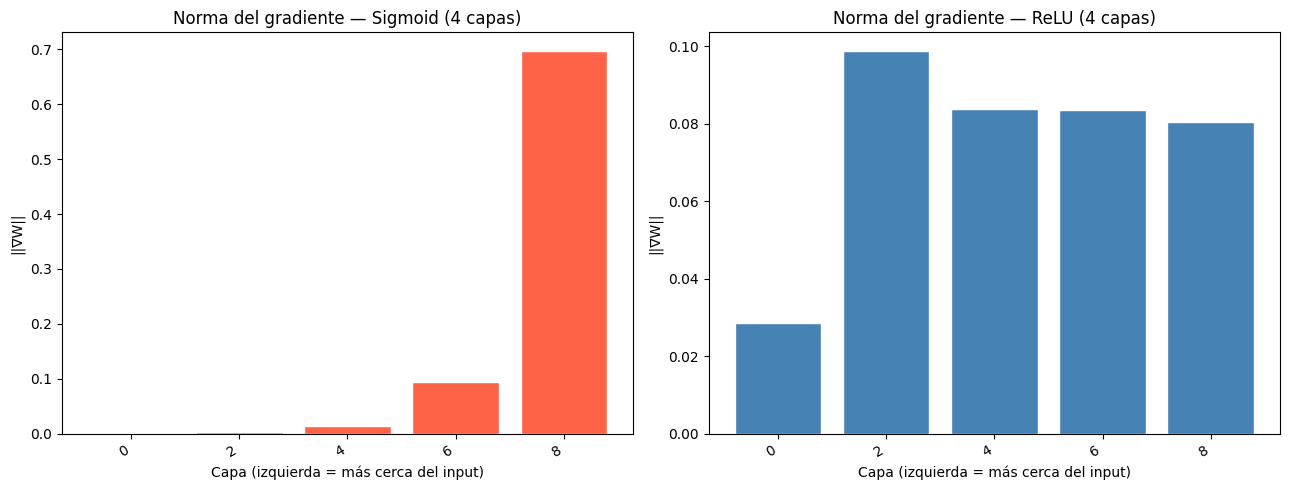

In [60]:
# Gradientes por capa

# Entrenamos brevemente un modelo con sigmoid para comparar contra ReLU
class NetSigmoid(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, output_dim=1, n_layers=4):
        super(NetSigmoid, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Sigmoid()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid()]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class NetReLU(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, output_dim=1, n_layers=4):
        super(NetReLU, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def get_grad_norms(model_class, X_t, y_t, n_steps=50):
    """
    Realiza n_steps de entrenamiento y registra la norma del gradiente
    de cada capa lineal al final.
    """
    torch.manual_seed(SEED)
    m = model_class().to(device)
    opt = optim.SGD(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()

    for _ in range(n_steps):
        m.train()
        opt.zero_grad()
        loss = crit(m(X_t), y_t)
        loss.backward()
        opt.step()

    # Recolectar normas del gradiente por capa lineal
    grad_norms = []
    layer_names = []
    for name, param in m.named_parameters():
        if "weight" in name and param.grad is not None:
            grad_norms.append(param.grad.norm().item())
            layer_names.append(name.replace(".weight", ""))

    return layer_names, grad_norms

names_sig, norms_sig = get_grad_norms(NetSigmoid, X_train_t, y_train_t)
names_rel, norms_rel = get_grad_norms(NetReLU, X_train_t, y_train_t)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, names, norms, title, color in [
    (axes[0], names_sig, norms_sig, "Sigmoid (4 capas)", "tomato"),
    (axes[1], names_rel, norms_rel, "ReLU (4 capas)", "steelblue"),
]:
    ax.bar(range(len(norms)), norms, color=color, edgecolor="white")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.split(".")[-1] for n in names], rotation=30, ha="right")
    ax.set_title(f"Norma del gradiente — {title}")
    ax.set_ylabel("||∇W||")
    ax.set_xlabel("Capa (izquierda = más cerca del input)")

plt.tight_layout()
plt.show()

#### **Pregunta 6.1**
**Pega las dos gráficas. ¿Ves diferencia entre la red con Sigmoid y la red con ReLU en cuanto a cómo se distribuyen los gradientes entre capas? ¿La primera capa (más a la izquierda) recibe gradientes de magnitud comparable a la última? Conecta lo que ves con la explicación de vanishing gradients de los slides 40–41 del lunes.**

En la red con Sigmoid, los gradientes tienden a disminuir considerablemente en las capas más cercanas al input. Es decir, las primeras capas (las que están más a la izquierda en la gráfica) reciben gradientes mucho más pequeños que las capas finales. Esto indica que durante backpropagation la señal del gradiente se va reduciendo a medida que atraviesa las capas, lo que es precisamente el fenómeno conocido como _vanishing gradient_.

En cambio, en la red con ReLU los gradientes suelen mantenerse más uniformes entre capas. Las primeras capas reciben gradientes de magnitud más comparable a las capas finales, lo que significa que pueden actualizar sus pesos de manera más efectiva durante el entrenamiento.

#### **Pregunta 6.2**
**En el código usamos optim.SGD en lugar de Adam deliberadamente para este experimento. ¿Por qué Adam podría enmascarar el efecto del vanishing gradient y hacer menos visible la diferencia?**

Se emplea SGD en lugar de Adam porque Adam podría ocultar parcialmente el efecto del vanishing gradient.

Adam ajusta automáticamente el tamaño del paso de cada parámetro utilizando estimaciones del primer y segundo momento de los gradientes. Esto significa que incluso cuando un gradiente es muy pequeño, Adam puede escalar la actualización y seguir realizando cambios relativamente efectivos en los pesos.

Como resultado, las capas que reciben gradientes pequeños podrían seguir actualizándose gracias al mecanismo adaptativo del optimizador. Esto haría que el problema de _vanishing gradients_ fuera menos visible en la práctica, aunque siga existiendo a nivel de derivadas.

En cambio, SGD utiliza directamente el gradiente calculado, sin escalamiento adaptativo. Si el gradiente que llega a una capa es muy pequeño, la actualización de sus pesos también será muy pequeña. Por eso el efecto de _vanishing gradient_ se observa más claramente cuando se usa SGD.

## **Parte 7: Depuración (encuentra el error)**
El siguiente código tiene tres errores deliberados. Cada uno produce o un resultado silenciosamente incorrecto o un crash. Encuéntralos, explica por qué cada uno es un error, y corrígelos.

No uses el stack trace como única guía: algunos errores no hacen crash, solo producen resultados incorrectos.

In [61]:
# ── CÓDIGO CON ERRORES ──────────────────────────────────────────────
scaler_debug = StandardScaler()
X_train_bug = scaler_debug.fit_transform(X_train)
X_test_bug = scaler_debug.transform(X_test)      # ERROR 1 <----------------------------------------- (corregido)

torch.manual_seed(SEED)
model_debug = ConcreteNet(8, 64, 1).to(device)
opt_debug = optim.Adam(model_debug.parameters(), lr=1e-3)
crit_debug = nn.MSELoss()

X_tr = to_tensor(X_train_bug)
y_tr = to_tensor(y_train_sc)

for epoch in range(50):
    model_debug.train()
    for Xb, yb in DataLoader(TensorDataset(X_tr, y_tr), batch_size=32):
        loss = crit_debug(model_debug(Xb), yb)
        opt_debug.zero_grad()
        loss.backward()                                 # ERROR 2 <--------------------------------------- (corregido)
        opt_debug.step()

model_debug.eval()
X_test_debug = to_tensor(X_test_bug) # Se agrega línea de código para corrección del ERROR 3
y_debug_pred = model_debug(X_test_debug).detach().numpy()  # ERROR 3 <----------------------------------------- (corregido)

print(f"Predicción ejemplo: {y_debug_pred[0]}")

Predicción ejemplo: [-1.6552875]


#### **Pregunta 7.1**
**Identifica los tres errores. Para cada uno:**

**a) Señala la línea exacta y el comentario que lo marca.**

**b) Explica por qué es un error (qué produce que es incorrecto o problemático).**

**c) Escribe la corrección.**

**ERROR 1:**
- Línea `X_test_bug = scaler_debug.fit_transform(X_test)`
- Se está usando `fit_transform()` en el conjunto de test, lo que hace que el StandardScaler aprenda la media y desviación del test set.
Esto introduce información del conjunto de prueba en el entrenamiento, lo cual produce data leakage y una evaluación incorrecta del modelo.
- **Corrección:** El scaler debe ajustarse solo con el train set. Se corrige la línea a: `X_test_bug = scaler_debug.transform(X_test)`

**ERROR 2:**
- A partir de la línea de `loss.backward` hasta `opt_debug.zero_grad()`
- Como los gradientes se acumulan en PyTorch, si no se limpian antes de calcular el backward, los gradientes de iteraciones anteriores afectan la actualización actual. El orden correcto es primero limpiar gradientes, luego el backward y por último actualizar pesos
- **Corrección:** Se corrige el orden de las líneas de código al siguiente:

  `opt_debug.zero_grad()`

  `loss.backward()`

  `opt_debug.step()`

**ERROR 3:**
- Línea `y_debug_pred = model_debug(X_test_t).detach().numpy()`
- El modelo se entrena con datos escalados con scaler_debug, pero predice con otros datos escalados.
- **Corrección:** Se agrega línea de código `X_test_debug = to_tensor(X_test_bug)` almacenando los datos correctos en tensor con los que el modelo va a predecir y se corrige el nombre de la variable contenido en la línea señalada del error a: `y_debug_pred = model_debug(X_test_debug).detach().numpy()`

## **Parte 8: Comparación final y análisis crítico**


In [62]:
# Ridge como línea base
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Ridge con búsqueda de alpha en el mismo train set
ridge_cv = GridSearchCV(
    Ridge(), {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=5, scoring="neg_mean_squared_error"
)
ridge_cv.fit(X_train_sc, y_train_sc.ravel())
print(f"Mejor alpha Ridge: {ridge_cv.best_params_['alpha']}")

y_ridge_sc = ridge_cv.predict(X_test_sc).reshape(-1, 1)
y_ridge_mpa = scaler_y.inverse_transform(y_ridge_sc)
rmse_ridge = np.sqrt(mean_squared_error(y_true_mpa, y_ridge_mpa))
mae_ridge = np.mean(np.abs(y_true_mpa - y_ridge_mpa))

print(f"\nComparación final:")
print(f"{'Modelo':<35} {'RMSE (MPa)':>12} {'MAE (MPa)':>12} {'Parámetros':>12}")
print("-" * 75)
print(f"{'Ridge (mejor alpha)':<35} {rmse_ridge:>12.2f} {mae_ridge:>12.2f} {'9':>12}")
print(f"{'Red Neuronal (base 2x64)':<35} {rmse_nn:>12.2f} {mae_nn:>12.2f}")

Mejor alpha Ridge: 0.01

Comparación final:
Modelo                                RMSE (MPa)    MAE (MPa)   Parámetros
---------------------------------------------------------------------------
Ridge (mejor alpha)                        11.04         8.84            9
Red Neuronal (base 2x64)                    5.22         3.61


#### **Pregunta 8.1**
**Llena la tabla. ¿Cuál modelo tiene menor RMSE? ¿La diferencia es estadísticamente y prácticamente significativa?**

El modelo con menor RMSE es la Red Neuronal en arquitectura Base(2x64).

La diferencia entre los modelos es grande tanto estadística como prácticamente. El RMSE de la red neuronal es aproximadamente la mitad del RMSE del modelo Ridge. Esto indica que la red neuronal produce predicciones considerablemente más cercanas a los valores reales.

Además, el MAE también es mucho menor en la red neuronal, lo que refuerza la conclusión de que el modelo no lineal captura mejor la relación entre las variables de entrada y la resistencia del concreto.

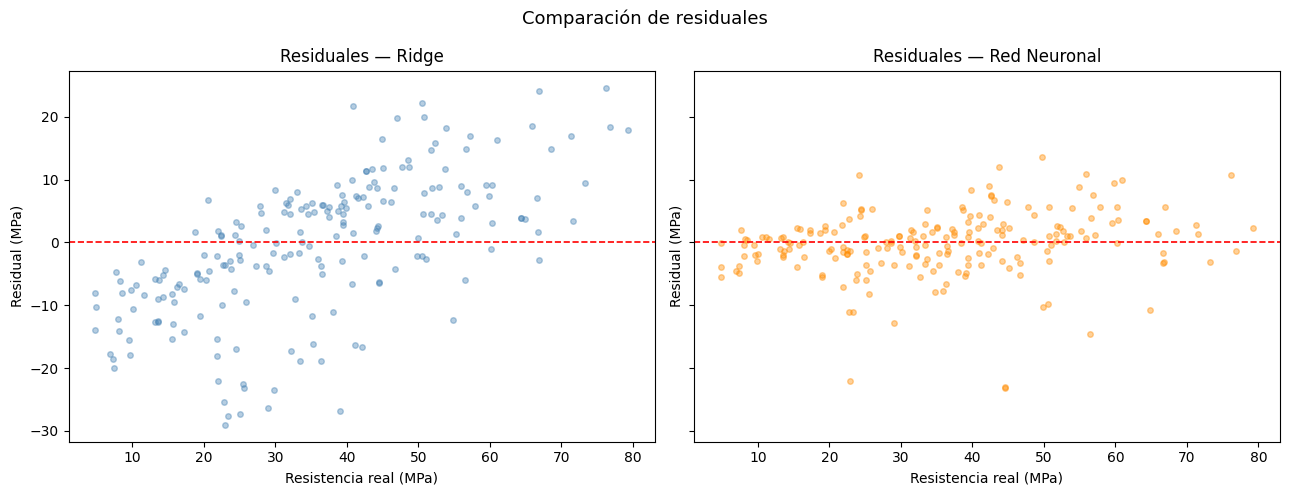

In [63]:
# Gráfica comparativa de residuales
resid_ridge = y_true_mpa.flatten() - y_ridge_mpa.flatten()
resid_nn = y_true_mpa.flatten() - y_pred_mpa.flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, resid, title, color in [
    (axes[0], resid_ridge, "Residuales — Ridge",          "steelblue"),
    (axes[1], resid_nn,    "Residuales — Red Neuronal",   "darkorange"),
]:
    ax.scatter(y_true_mpa, resid, alpha=0.4, s=16, color=color)
    ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Resistencia real (MPa)")
    ax.set_ylabel("Residual (MPa)")
    ax.set_title(title)

plt.suptitle("Comparación de residuales", fontsize=13)
plt.tight_layout()
plt.show()

#### **Pregunta 8.2**
**Pega la gráfica. ¿Hay diferencias en el patrón de residuales entre los dos modelos? ¿Alguno tiene sesgos sistemáticos que el otro no tiene?**

En el modelo Ridge, los residuales muestran un patrón: para valores bajos de resistencia real, los residuales tienden a ser negativos, mientras que para valores altos tienden a ser positivos. Esto indica que el modelo sobreestima resistencias bajas y subestima resistencias altas, generando una tendencia creciente en los residuales, sugiriendo que el modelo lineal no está capturando correctamente la relación entre las variables.

En cambio, en la red neuronal, los residuales se encuentran más dispersos alrededor de cero sin un patrón claro a lo largo de los valores de resistencia real. Esto indica que el modelo no presenta un sesgo evidente y que las predicciones son más equilibradas a lo largo de todo el rango de valores.

### **La pregunta que importa**
#### **Pregunta 8.3**

**Tu red neuronal base tiene entre 4,000 y 20,000 parámetros dependiendo de la arquitectura que elegiste. Ridge tiene 9. Con esa diferencia en mente, y con los resultados en la mano, responde las siguientes preguntas con argumentos, no solo con el número de RMSE:**

**a) ¿La diferencia en RMSE es prácticamente significativa para el problema de ingeniería civil? En concreto estructural, un error de 2 MPa puede ser relevante o irrelevante según el contexto de uso. ¿Qué contextos harían esa diferencia crítica y cuáles no?**

Sí, la diferencia puede ser prácticamente significativa dependiendo del contexto. La red neuronal reduce el error de aproximadamente 11 MPa a 5 MPa, lo que implica una mejora considerable en la precisión de las predicciones.

En ingeniería estructural, una diferencia de **2 MPa o más** puede ser crítica en ciertos contextos. Por ejemplo, cuando el concreto está diseñado para cumplir una resistencia mínima específica (por ejemplo, 30 MPa o 40 MPa), un error grande podría llevar a estimar que una mezcla cumple con la especificación cuando en realidad no lo hace, lo que podría comprometer la seguridad estructural.

Una estimación más precisa puede ser muy importante porque las decisiones de diseño dependen directamente de la resistencia del material.

En cambio, en contextos menos críticos como estimaciones preliminares, planificación de producción de concreto o análisis exploratorio de mezclas, una diferencia de algunos MPa podría no ser tan relevante, ya que las decisiones finales se basan en factores de seguridad adicionales.

**b) Si tuvieras que presentar tus resultados a un comité de ingenieros civiles que no saben nada de machine learning, ¿cuál modelo presentarías y por qué? Piensa en interpretabilidad, confianza del cliente y riesgo.**

Dependería del objetivo del análisis, pero probablemente presentaría ambos modelos, destacando el rol de cada uno.

El modelo Ridge tiene una ventaja importante: es simple e interpretable. Cada coeficiente representa directamente la relación entre una variable de entrada y la resistencia del concreto, lo que facilita que los ingenieros entiendan cómo influyen los componentes de la mezcla.

Por otro lado, la red neuronal ofrece una precisión mucho mayor. Esto sugiere que captura relaciones más complejas entre los ingredientes del concreto que un modelo lineal no puede representar.

Para un comité de ingenieros, una estrategia razonable sería presentar el modelo Ridge como referencia interpretable y la red neuronal como una herramienta predictiva más precisa.

**c) ¿Qué agregarías al dataset o qué cambiarías del planteamiento del problema para que una red neuronal tuviera una ventaja más clara sobre regresión lineal? Argumenta en términos de qué hace a las redes neuronales mejores que los modelos lineales.**

Las redes neuronales suelen destacar cuando los datos contienen relaciones altamente no lineales o interacciones complejas entre variables.

Para que una red neuronal tenga una ventaja más clara sobre un modelo lineal, sería útil incluir variables adicionales que capturen mejor la complejidad del proceso de formación del concreto, por ejemplo:

- Condiciones ambientales durante el curado (temperatura, humedad)
- Tiempo de curado más detallado o mediciones a diferentes edades
- Propiedades físicas de los agregados
- Información química del cemento y/o aditivos

Estos factores pueden interactuar de manera no lineal, algo que una red neuronal puede modelar mejor que una regresión lineal. Con más variables complejas y mayor cantidad de datos, la capacidad de las redes neuronales para aprender interacciones y efectos no lineales se vuelve más ventajosa.

**d) ¿Hay consideraciones éticas en usar un modelo de caja negra para tomar decisiones de diseño estructural? Identifica al menos dos y explica quién asume el riesgo si el modelo se equivoca.**

Sí existen consideraciones éticas importantes al usar modelos de caja negra en decisiones de ingeniería estructural.

Una primera preocupación es la falta de interpretabilidad. Si un modelo complejo produce una predicción incorrecta, puede ser difícil entender por qué ocurrió el error. Esto puede complicar la verificación del modelo y reducir la confianza de los ingenieros que deben tomar decisiones basadas en sus resultados.

Una segunda preocupación es la responsabilidad en caso de fallo. Si un modelo de ML se utiliza para apoyar decisiones de diseño y produce una predicción incorrecta que contribuye a un fallo estructural, surge la pregunta de quién asume el riesgo: el ingeniero que usó el modelo, el desarrollador del modelo o la organización que lo implementó.

Por estas razones, en aplicaciones críticas como el diseño estructural, los modelos de machine learning deberían utilizarse como herramientas de apoyo a la decisión, complementando el juicio de ingeniería, las normativas de diseño y las pruebas experimentales, en lugar de reemplazarlos completamente.

---

## **Parte 9: Reflexión sin código**

#### **Pregunta 9.1**
**En el training loop escribiste loss.backward(). Explica qué está calculando PyTorch en esa línea en términos de la regla de la cadena. No necesitas matemática formal: usa la analogía de la cadena de responsabilidad que viste en clase y aplícala concretamente a la primera capa lineal de tu red.**

Cuando se ejecuta `loss.backward()`, PyTorch calcula automáticamente los gradientes de la función de pérdida con respecto a todos los parámetros de la red usando backpropagation y la regla de la cadena.

Es verdad que la idea puede entenderse como una cadena de responsabilidad, porque cada capa de la red recibe la responsabilidad de decir cómo contribuyó al error final y luego pasa esa información a la capa anterior.

Primero se calcula cuánto cambia la pérdida respecto a la predicción final del modelo. Después, cada capa calcula cuánto influyó su salida en ese error y transmite esa información hacia atrás.

Pensando en la primera capa lineal, esta recibe un gradiente que ya ha pasado por todas las capas posteriores. Esa señal indica cuánto debería cambiar la salida de esa capa para reducir el error final. La primera capa entonces calcula cuánto influyen sus pesos en su salida y ajusta sus parámetros en consecuencia.

#### **Pregunta 9.2**
**El Teorema de Aproximación Universal (Cybenko, 1989) dice que una red con una sola capa oculta puede aproximar cualquier función continua. Tienes 1,030 muestras. Hay al menos tres razones distintas por las que ese teorema no garantiza RMSE cercano a cero en este dataset. Menciona tres y explica cada una.**

**1. Cantidad limitada de datos**

El teorema asume que tenemos suficiente información para aprender la función real. En este dataset solo hay **1,030 muestras**, lo cual puede no ser suficiente para capturar con precisión todas las relaciones entre las variables. Si los datos no cubren bien todo el espacio de posibles mezclas de concreto, el modelo no puede aprender correctamente la función subyacente.

**2. Ruido en los datos**

Las mediciones experimentales de resistencia del concreto tienen variabilidad natural. Factores como condiciones de laboratorio, variaciones en materiales o errores de medición introducen ruido en los datos. Incluso un modelo perfecto no puede predecir exactamente valores que contienen ruido aleatorio.

**3. Limitaciones prácticas del entrenamiento**

El teorema es un resultado teórico que no considera problemas prácticos como optimización imperfecta, regularización, arquitectura limitada o entrenamiento incompleto. En la práctica, el modelo puede quedarse atrapado en soluciones subóptimas o no tener suficiente capacidad para aproximar la función real con precisión.

#### **Pregunta 9.3**
**En alguno de tus experimentos, ¿el val loss fue consistentemente menor que el train loss durante varias epochs? Si sí ocurrió, explica por qué es posible eso. Si no ocurrió, describe en qué condiciones podría ocurrir y qué significaría.**

Hay cierta similitud de valores existente en los experimentos, aunque cabe mencionar que no fue consistente.

Esto puede suceder cuando el entrenamiento incluye técnicas que introducen ruido o regularización, como Dropout o Data Augmentation. Durante el entrenamiento, el modelo ve datos ligeramente perturbados o tiene neuronas desactivadas aleatoriamente, lo que hace que el problema sea más difícil. En cambio, durante la validación esas perturbaciones no están presentes, por lo que el modelo puede obtener un error menor.

Otra razón posible es que el _training set_ sea ligeramente más difícil o más ruidoso que el _validation set_ debido a la forma en que se dividieron los datos.

En general, cuando el _validation loss_ es ligeramente menor que el _training loss_, suele indicar que la regularización está funcionando correctamente y que el modelo no está sobreajustando demasiado al conjunto de entrenamiento.

#### **Pregunta 9.4**
**Describe qué tendría que ser diferente en este problema (dataset, tarea, objetivo de negocio) para que hubieras tomado la decisión de usar una red neuronal sin hesitar. Sé específico: no digas "más datos", sino cuántos datos y qué tipo de relación entre variables justificaría la complejidad adicional.**

Usaría una red neuronal sin dudar si el problema tuviera mucha más información y relaciones claramente no lineales entre variables.

Por ejemplo, si el dataset tuviera decenas o cientos de miles de muestras, con muchas variables adicionales relacionadas con el proceso de producción del concreto, una red neuronal podría aprovechar mejor esa complejidad.

Algunas variables adicionales que justificarían el uso de una red neuronal podrían ser:

- condiciones ambientales durante el curado (temperatura, humedad)
- propiedades químicas detalladas del cemento
- características físicas de los agregados
- mediciones del proceso de mezclado
- evolución de la resistencia en diferentes edades

Con suficientes datos y variables complejas, la relación entre las entradas y la resistencia del concreto probablemente sería altamente no lineal e interactiva, lo cual es exactamente el tipo de problema donde las redes neuronales tienen una ventaja clara sobre modelos lineales.

#### **Pregunta 9.5**
**A lo largo de esta actividad construiste una red neuronal desde cero. Identifica el momento en el que entendiste algo que antes era confuso — puede ser un concepto del entrenamiento, un resultado de un experimento, o la razón de existir de una línea de código. Descríbelo con precisión.**

Un momento en el que algo realmente me hizo “clic” fue cuando comparé los residuales del modelo Ridge con los de la red neuronal.

Antes de ver esa gráfica, estaba pensando principalmente en términos de métricas como el RMSE. Sabía que la red neuronal tenía un error menor, pero no tenía tan claro *por qué* estaba funcionando mejor.

Cuando vi la gráfica de residuales, se volvió mucho más evidente. El modelo Ridge mostraba un patrón claro: tendía a sobreestimar resistencias bajas y subestimar resistencias altas. Eso me hizo entender que el modelo lineal estaba tratando de ajustar una relación que probablemente no es completamente lineal.

En cambio, los residuales de la red neuronal estaban mucho más dispersos alrededor de cero y sin un patrón tan claro. Ahí entendí mejor que el objetivo del modelo no es solo bajar una métrica numérica, sino capturar la estructura real de los datos.

Ese momento también me ayudó a conectar la teoría con la práctica: las redes neuronales pueden modelar relaciones más complejas que un modelo lineal, y en este caso eso se reflejaba directamente en cómo se distribuían los errores.